# Clustering

Trying multiple clustering approaches and visualizing the results using T-SNE. For finding the optimal number of clusters we choose Silhouette Method and Elbow Method where possible. 

## Imports

In [38]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cdist, pdist
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, pairwise_distances
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")
 
import utils

## Loading the Data

In [29]:
df = pd.read_csv("../Data/final_cleaned_dataset.csv", index_col=0)

labels_df = df[['CountryCode', 'CountryName']]
numerical_features_df = df.drop(columns=['CountryCode', 'CountryName'])

In [30]:
numerical_features_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 0 to 88
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TourismEmploymentPer1000  89 non-null     float64
 1   TourismGDPPercentage      89 non-null     float64
 2   BusinessToPersonalRatio   89 non-null     float64
 3   AverageStayDays           89 non-null     float64
 4   InboundArrivalsPer1000    89 non-null     float64
 5   DomesticTouristsPer1000   89 non-null     float64
 6   InboundToOutboundRatio    89 non-null     float64
 7   GroceriesCostIndex        89 non-null     float64
 8   RestaurantPriceIndex      89 non-null     float64
 9   SafetyIndex               89 non-null     float64
 10  HealthCareIndex           89 non-null     float64
 11  ClimateIndex              89 non-null     float64
 12  ReverseTrafficIndex       89 non-null     float64
 13  ReversePollutionIndex     89 non-null     float64
dtypes: float64(14)
me

## K-Means Clustering

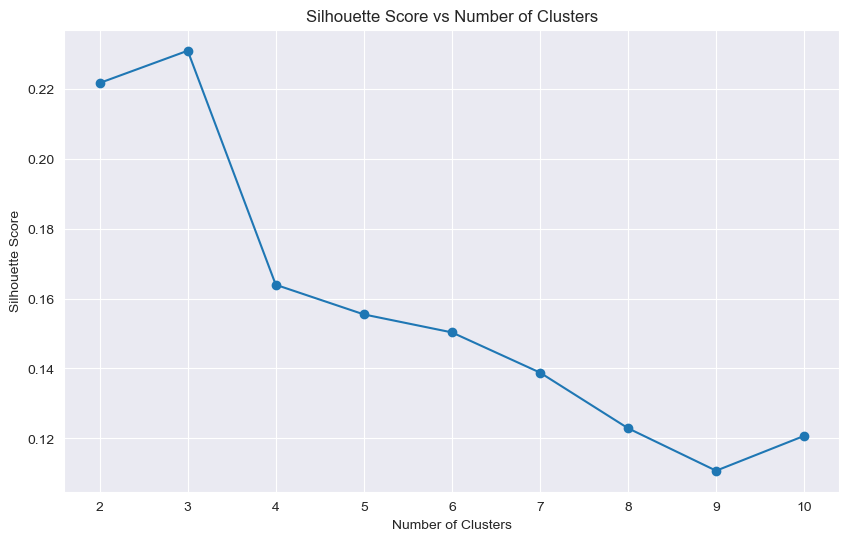

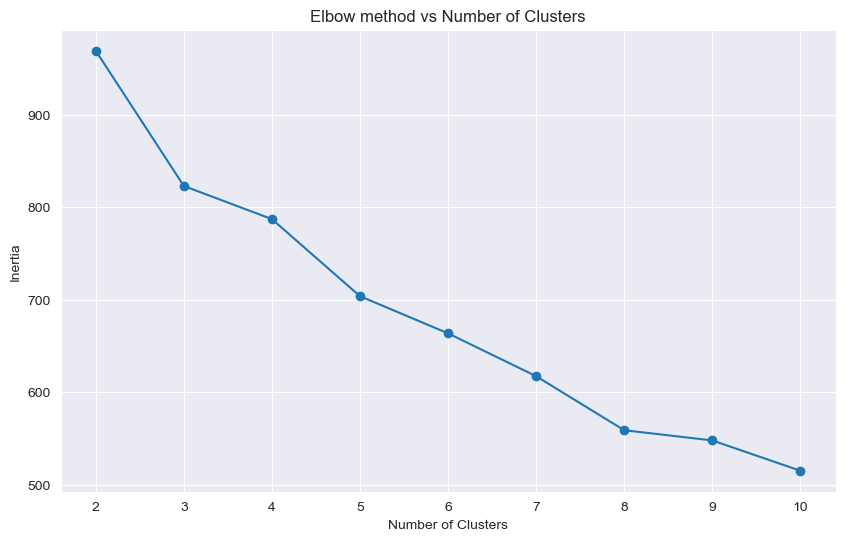

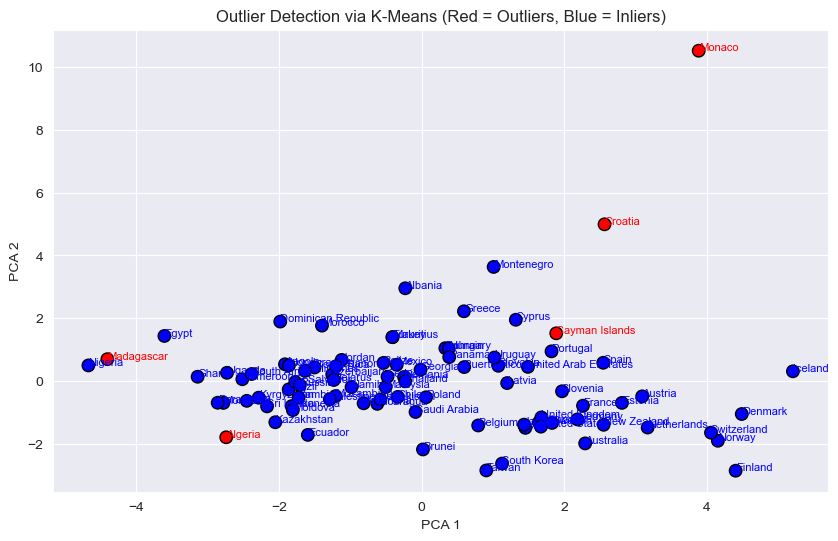

Outlier Countries:
['Algeria', 'Cayman Islands', 'Croatia', 'Madagascar', 'Monaco']


In [31]:
number_clusters = range(2, 11) #between 2 and 11 clusters
silhouette_scores, inertia = utils.getSilhouetteScoreAndInertiaForKMeans(number_clusters, numerical_features_df)
utils.plotValuesBasedOnClusterNumbers(number_clusters, silhouette_scores, "Number of Clusters", "Silhouette Score","Silhouette Score vs Number of Clusters")
utils.plotValuesBasedOnClusterNumbers(number_clusters, inertia, "Number of Clusters", "Inertia","Elbow method vs Number of Clusters")

#Choose the best k (based on max silhouette score)
best_k = number_clusters[inertia.index(max(inertia))]

#Run K-Means
kmeans_final = KMeans(n_clusters=best_k,random_state=43, n_init=10, max_iter=1000)
cluster_labels = kmeans_final.fit_predict(numerical_features_df)


# Get distances of each point to its assigned cluster centroid
centroids = kmeans_final.cluster_centers_
distances = np.linalg.norm(numerical_features_df - centroids[cluster_labels], axis=1)

# Define outliers (e.g., top 5% farthest points)
threshold = np.percentile(distances, 95)
outliers = distances > threshold

# Run PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(numerical_features_df)

plt.figure(figsize=(10, 6))

# Color points: red for outliers, blue otherwise
colors = ['red' if outliers[i] else 'blue' for i in range(len(outliers))]
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=colors, s=80, edgecolors='k')

# Annotate country names using same red/blue logic
for i, country in enumerate(df["CountryName"]):
    label_color = 'red' if outliers[i] else 'blue'
    plt.annotate(country, (pca_components[i, 0], pca_components[i, 1]), fontsize=8, color=label_color)

plt.title("Outlier Detection via K-Means (Red = Outliers, Blue = Inliers)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

# Print names of outlier countries
outlier_countries = df["CountryName"][outliers]
print("Outlier Countries:")
print(outlier_countries.to_list())

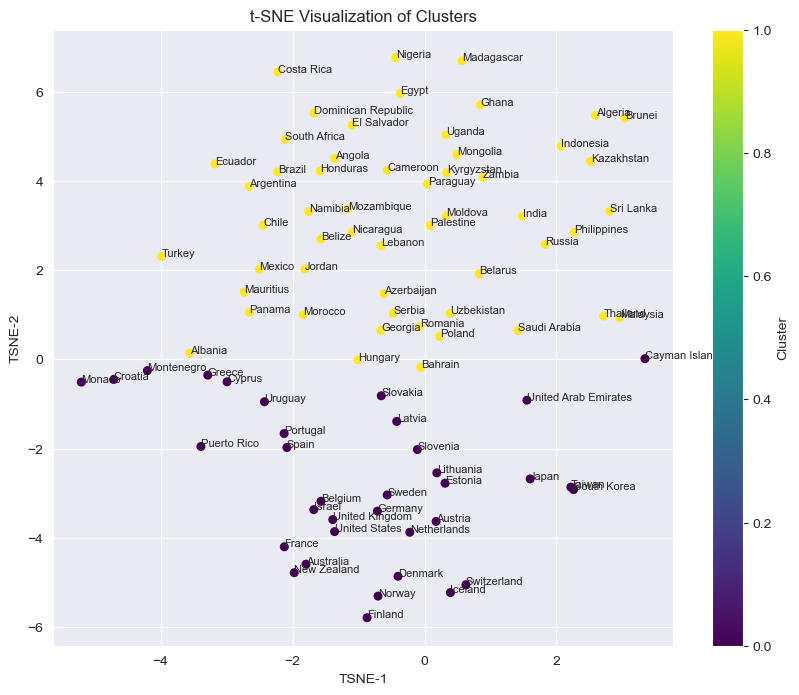

In [32]:

utils.applyTSNE(numerical_features_df, cluster_labels, df)

## Agglomerative (Hierarchical) Clustering



### 1: Evaluate Cluster Quality for Different `k`
We start by evaluating different choices for the number of clusters (`k`) using two methods:
- **Silhouette Score**: Measures how similar each point is to its own cluster vs. other clusters.
- **Elbow Method (KMeans Inertia)**: Measures the within-cluster sum of squares. We look for a point ("elbow") where adding more clusters yields diminishing returns.

These plots guide the selection of an appropriate `k`.

### 2: Visualize Cluster Structure via Dendrograms
We generate multiple **dendrograms** (tree diagrams) for `k = 1 to 10` to visually assess how the data naturally clusters. This helps validate our `k` choice and provides interpretability into the hierarchy of merges.

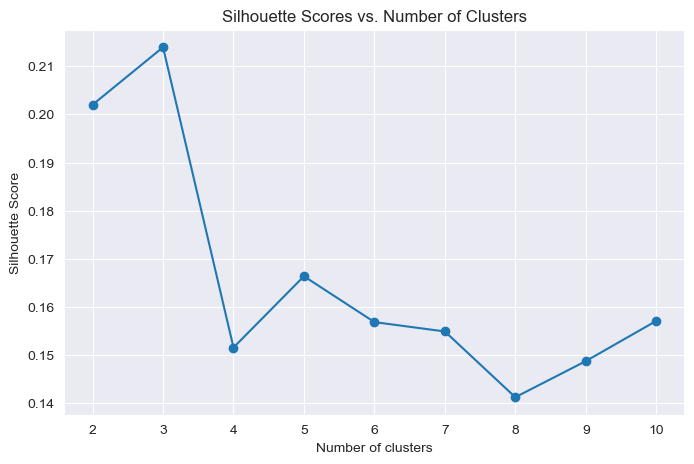

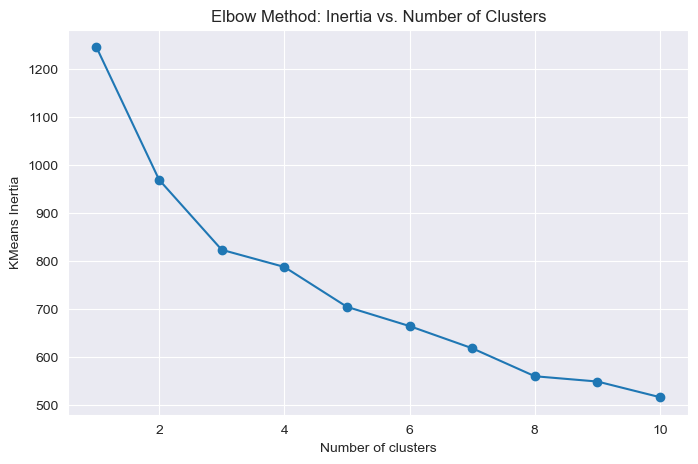

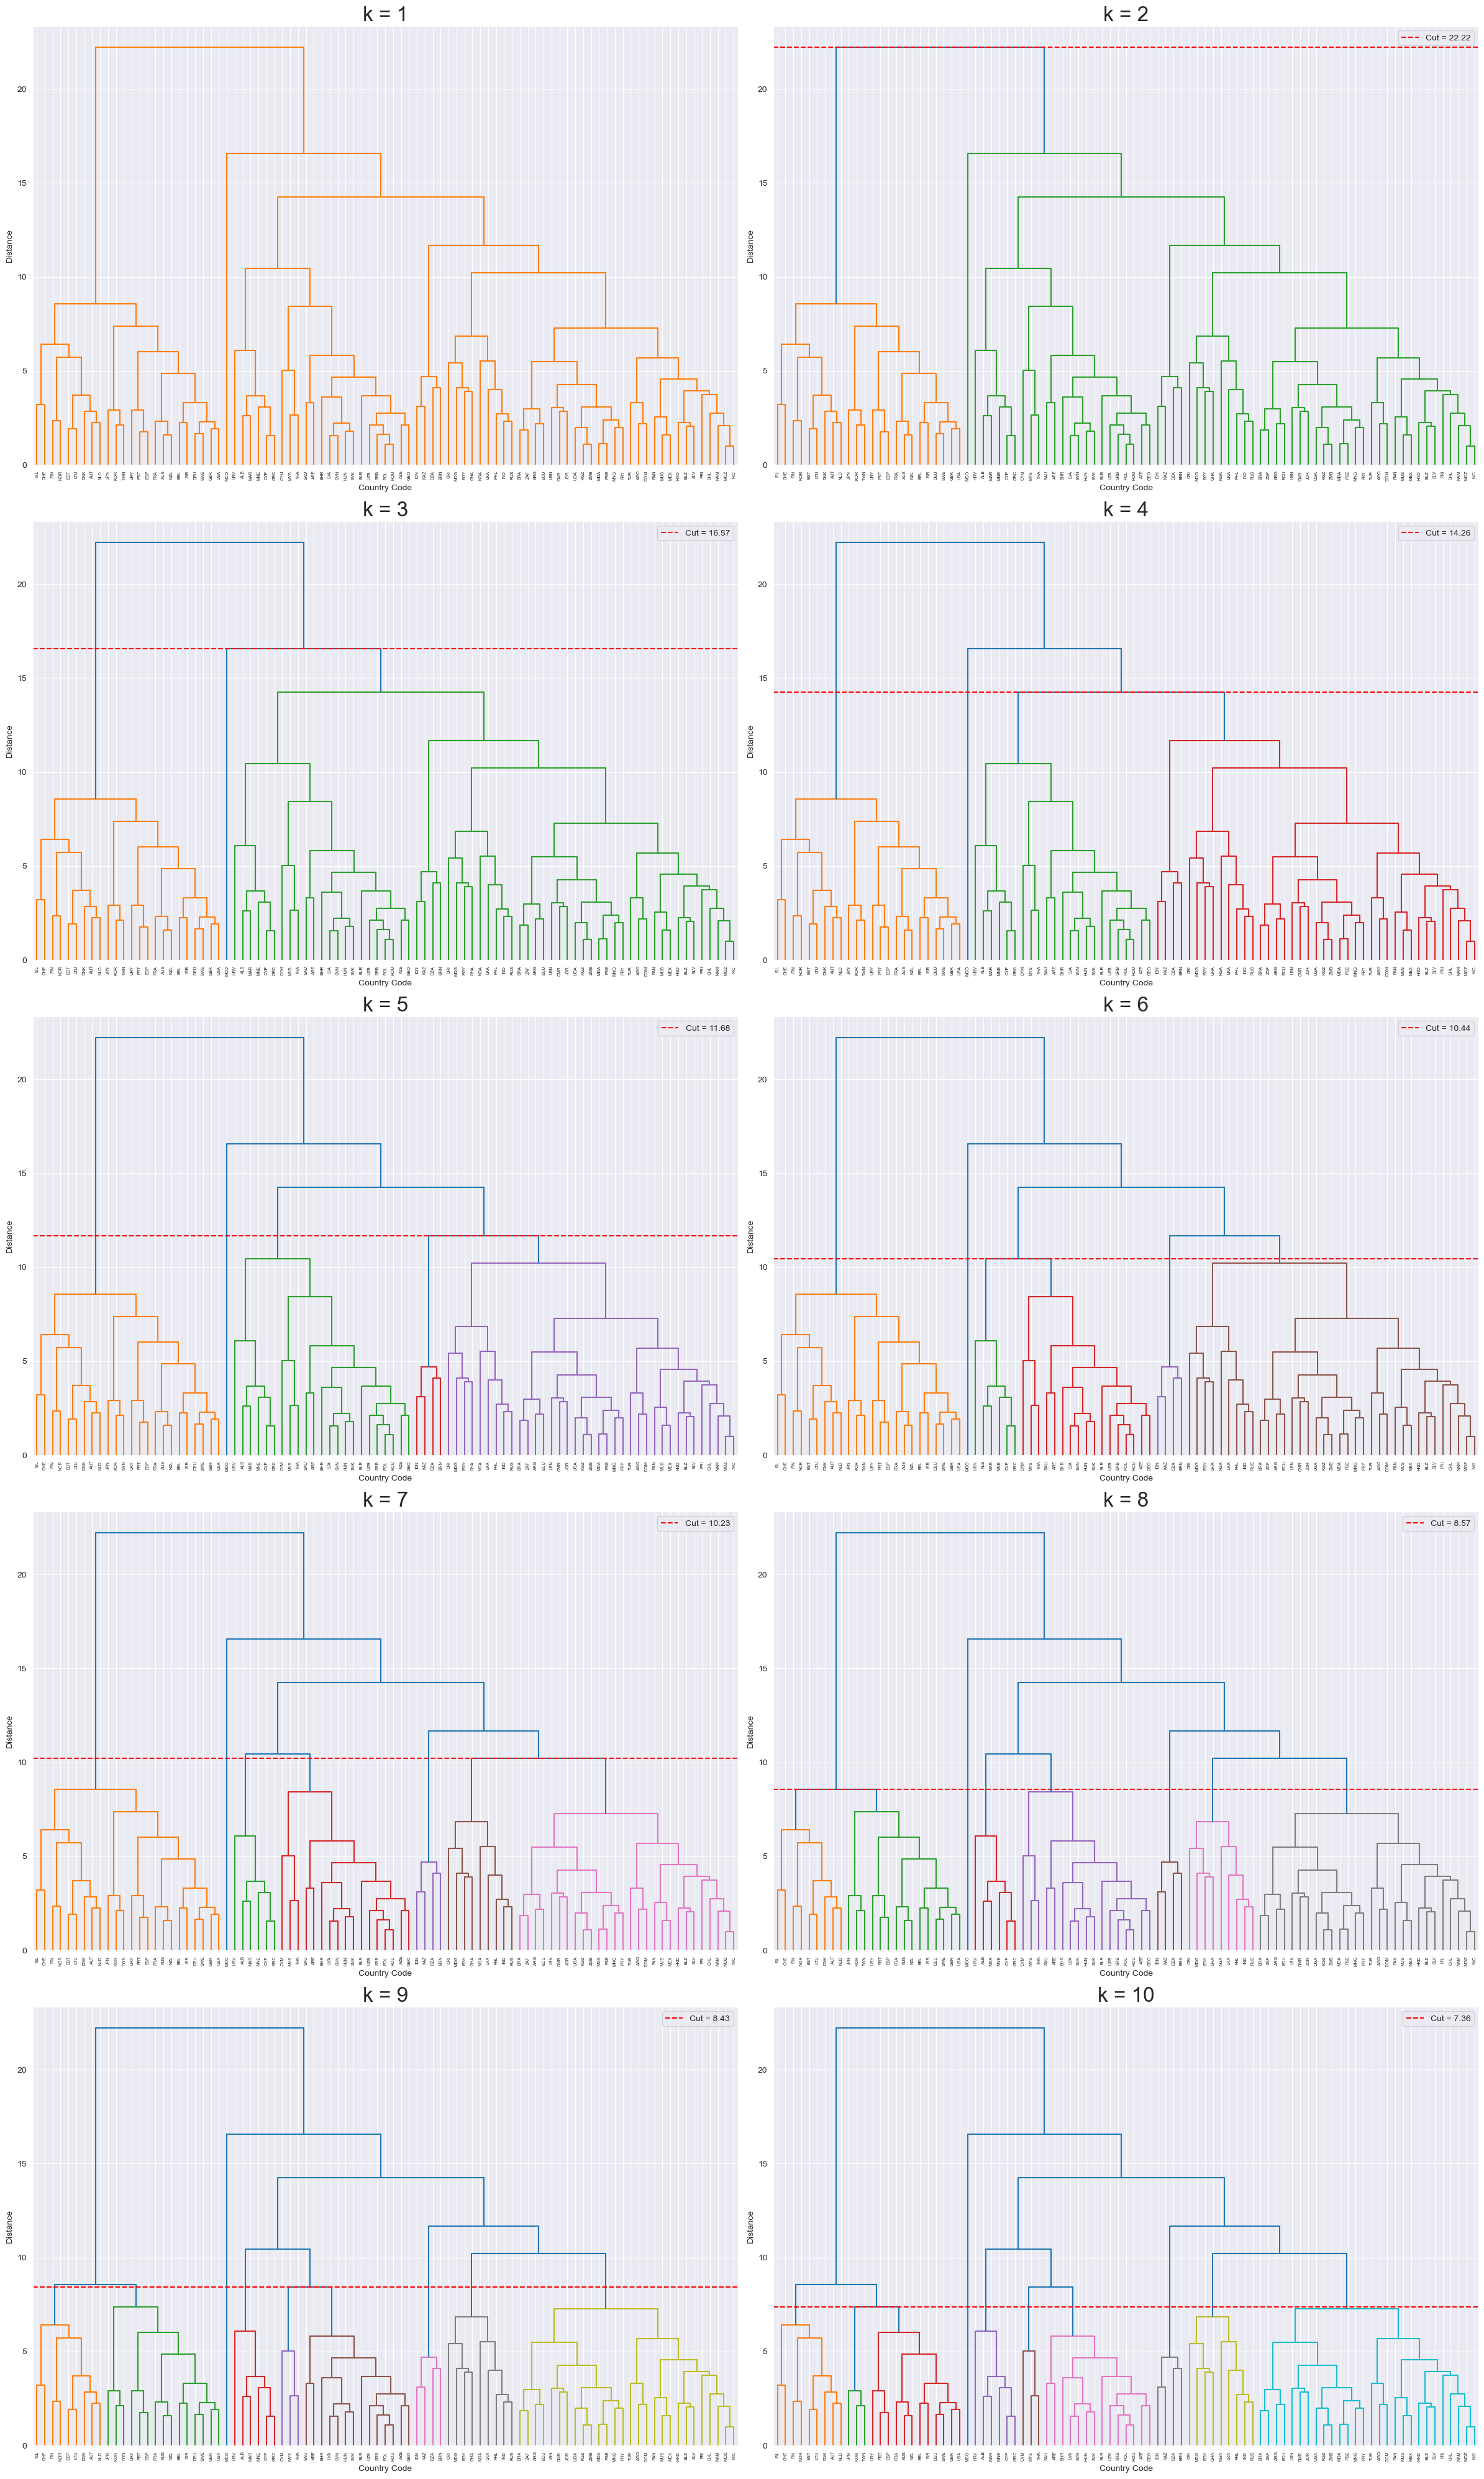

In [33]:
# Plot Silhouette and Elbow methods to aid in choosing the number of clusters
silhouette_scores = utils.plot_silhouette_scores(numerical_features_df, k_range=range(2, 11))
inertias = utils.plot_elbow_method(numerical_features_df, k_range=range(1, 11))

# Plot multiple dendrograms for k = 1 to 10 to visually compare cluster separations
utils.plot_multiple_dendrograms(numerical_features_df, countries=labels_df, max_k=10)

### 3: Perform Agglomerative Clustering
Using the selected number of clusters (`k_opt = 10`), we run the full hierarchical clustering pipeline:
- Optionally apply PCA (used to visualize in comparison with t-SNE, not used for final results).
- Fit an Agglomerative Clustering model.
- Attach cluster labels to countries and features.
- Visualize results in:
  - A full dendrogram for the chosen `k`
  - A **t-SNE scatter plot** colored by cluster, overlaid with country names for interpretability.

### 4: Validate Clustering Quality
We compute the following **validation metrics** to assess the quality of clustering:
- **Davies-Bouldin Index** (lower is better)
- **Calinski-Harabasz Index** (higher is better)
- **Dunn Index** (higher is better)

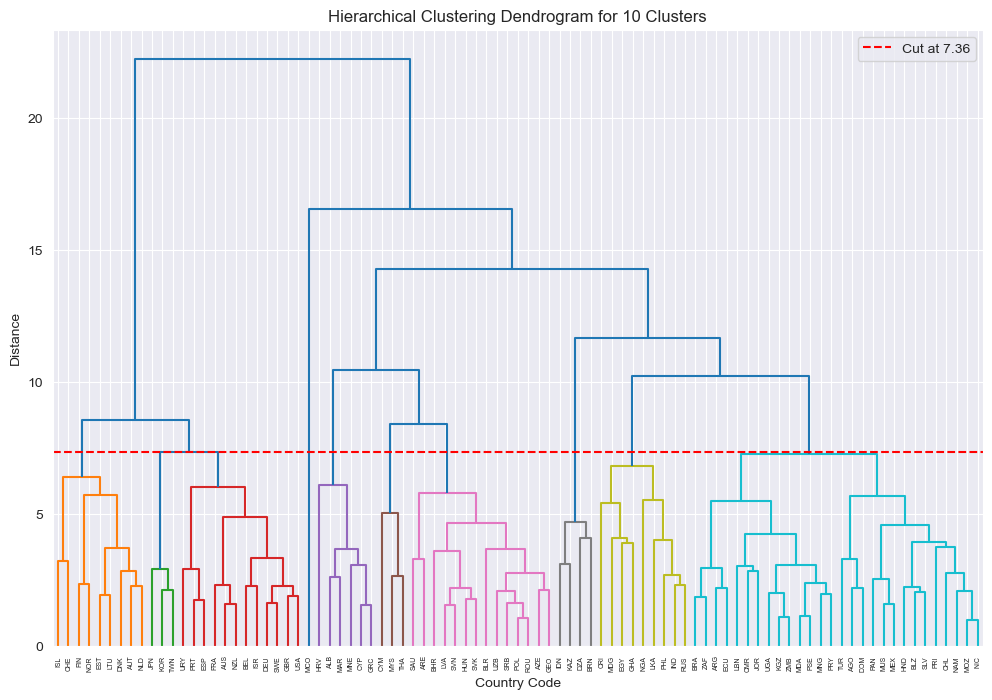

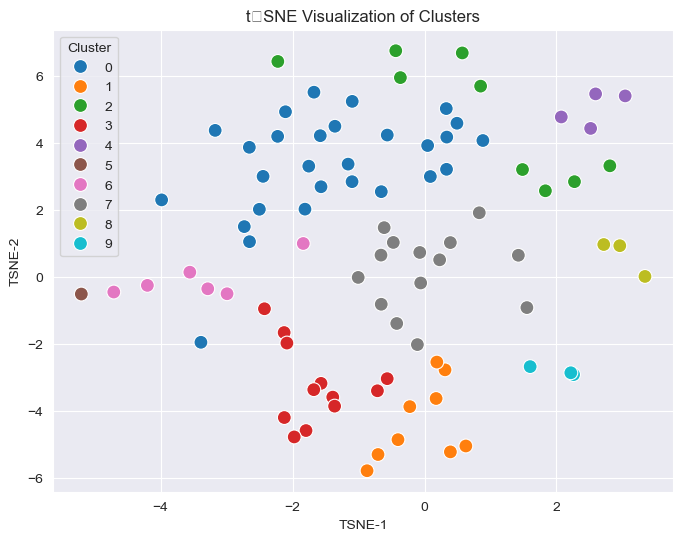

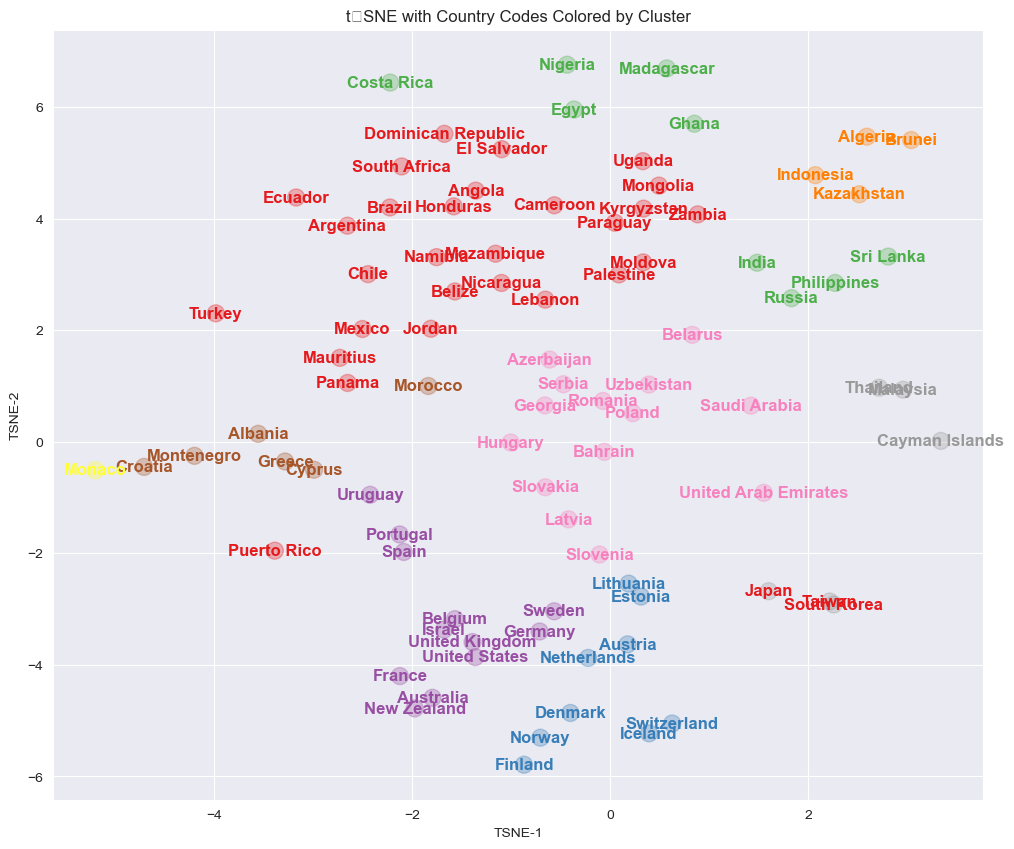

Validation Indices:
Davies-Bouldin Index: 1.3686682777175654
Calinski-Harabasz Index: 13.733544270799749
Dunn Index: 0.2913486719318367
Cluster mapping:
Cluster 0: Angola, Argentina, Belize, Brazil, Cameroon, Chile, Dominican Republic, Ecuador, El Salvador, Honduras, Jordan, Kyrgyzstan, Lebanon, Mauritius, Mexico, Moldova, Mongolia, Mozambique, Namibia, Nicaragua, Palestine, Panama, Paraguay, Puerto Rico, South Africa, Turkey, Uganda, Zambia
Cluster 1: Austria, Denmark, Estonia, Finland, Iceland, Lithuania, Netherlands, Norway, Switzerland
Cluster 2: Costa Rica, Egypt, Ghana, India, Madagascar, Nigeria, Philippines, Russia, Sri Lanka
Cluster 3: Australia, Belgium, France, Germany, Israel, New Zealand, Portugal, Spain, Sweden, United Kingdom, United States, Uruguay
Cluster 4: Algeria, Brunei, Indonesia, Kazakhstan
Cluster 5: Monaco
Cluster 6: Albania, Croatia, Cyprus, Greece, Montenegro, Morocco
Cluster 7: Azerbaijan, Bahrain, Belarus, Georgia, Hungary, Latvia, Poland, Romania, Saudi Ar

In [34]:
k_opt = 10
# Perform hierarchical clustering on the selected features using a chosen k
df_combined, cluster_labels, validation_indices = utils.run_clustering_analysis(
    numerical_features_df,
    countries=labels_df,
    k_clusters=k_opt,
    plot_dendrogram_flag=True,
    plot_tsne_flag=True,
    compute_validation=True
)

### Output
The final result is a `DataFrame` (`df_combined`) containing:
- Country information (CountryCode, CountryName)
- All features used in clustering
- Cluster assignments
- t-SNE coordinates for visualization

In [35]:
df_combined.head()

,CountryCode,CountryName,TourismEmploymentPer1000,TourismGDPPercentage,BusinessToPersonalRatio,AverageStayDays,InboundArrivalsPer1000,DomesticTouristsPer1000,InboundToOutboundRatio,GroceriesCostIndex,RestaurantPriceIndex,SafetyIndex,HealthCareIndex,ClimateIndex,ReverseTrafficIndex,ReversePollutionIndex,Cluster,TSNE-1,TSNE-2
0,ALB,Albania,-0.333946,1.118636,-0.783337,-0.452590,1.704074,-0.693972,1.349286,-0.166089,-0.107013,-0.127251,-1.841404,0.576221,0.784543,-1.155240,6,-3.557168,0.141412
1,DZA,Algeria,-0.606836,-1.037933,5.481195,-0.730933,-0.968930,-0.390089,-0.631519,-0.640480,-1.432562,-0.704632,-1.136995,-0.030294,-0.645321,-0.488936,4,2.593376,5.468632
2,AGO,Angola,-0.772379,-0.289399,-0.459332,-0.027572,-0.495962,-0.522824,1.381774,-0.592394,-0.648116,-1.705912,-0.458708,-0.019682,-0.831899,-0.558537,0,-1.357918,4.501501
3,ARG,Argentina,0.087578,-0.726562,-0.355807,-0.455681,-0.478210,-0.537437,-0.677670,-0.390107,-0.017525,-1.493962,0.372452,1.550446,-0.516069,0.177369,0,-2.655218,3.872975
4,AUS,Australia,-0.138995,-0.856744,0.146512,-0.554929,-0.194747,2.247780,-0.486190,1.645820,1.067524,-0.317275,0.976231,1.182042,-0.250376,1.398080,3,-1.796180,-4.590611


## DBScan

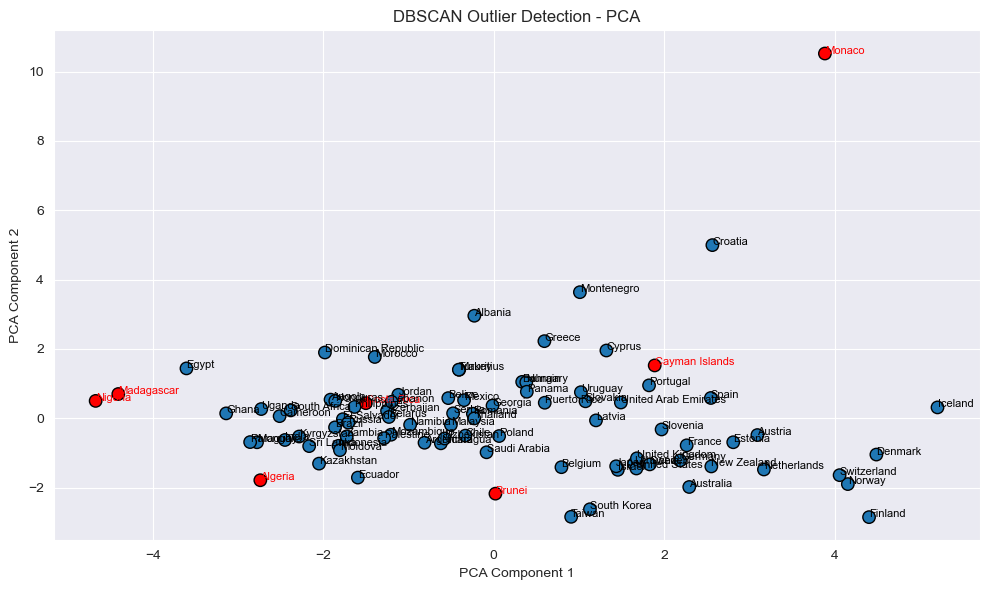

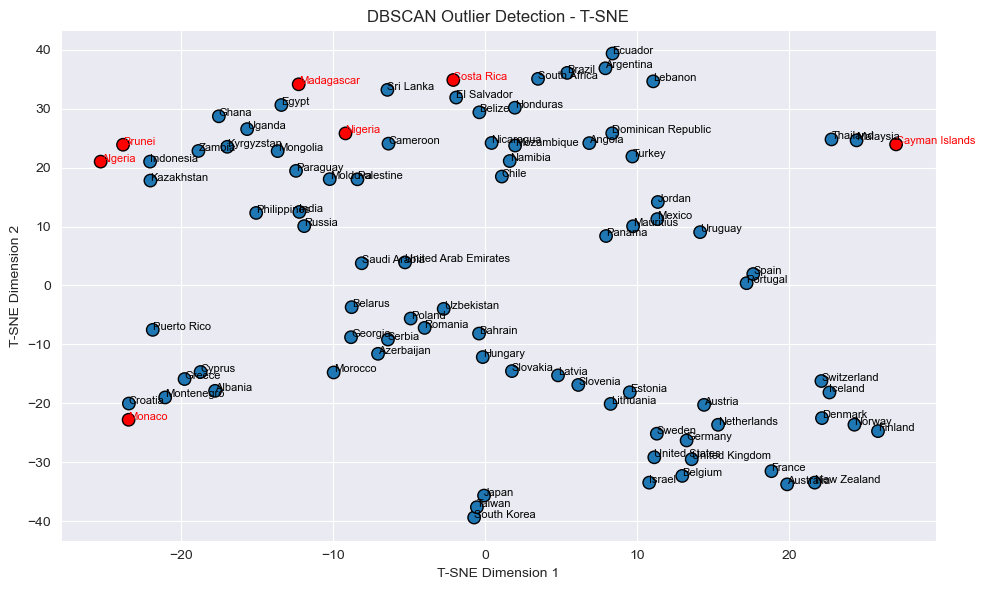


 Outlier Countries Detected:
       CountryName CountryCode
1          Algeria         DZA
12          Brunei         BRN
14  Cayman Islands         CYM
16      Costa Rica         CRI
44      Madagascar         MDG
49          Monaco         MCO
58         Nigeria         NGA

 Cleaned dataset contains 82 countries (out of 89)


In [36]:
from sklearn.cluster import DBSCAN
from sklearn.discriminant_analysis import StandardScaler


features = df.drop(columns=["CountryName", "CountryCode"])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

eps_value = 3.5          
min_samples_value = 2    

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(scaled_features)

# PCA Visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 6))
colors = ['#1f77b4' if label != -1 else '#ff0000' for label in labels]
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=colors, s=80, edgecolors='k')

for i, country in enumerate(df["CountryName"]):
    color = 'red' if labels[i] == -1 else 'black'
    plt.annotate(country, (pca_components[i, 0], pca_components[i, 1]), fontsize=8, color=color)

plt.title("DBSCAN Outlier Detection - PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# T-SNE Visualization
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
tsne_components = tsne.fit_transform(scaled_features)

plt.figure(figsize=(10, 6))
plt.scatter(tsne_components[:, 0], tsne_components[:, 1], c=colors, s=80, edgecolors='k')

for i, country in enumerate(df["CountryName"]):
    color = 'red' if labels[i] == -1 else 'black'
    plt.annotate(country, (tsne_components[i, 0], tsne_components[i, 1]), fontsize=8, color=color)

plt.title("DBSCAN Outlier Detection - T-SNE")
plt.xlabel("T-SNE Dimension 1")
plt.ylabel("T-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# List outlier countries
outlier_countries = df[labels == -1][["CountryName", "CountryCode"]]
print("\n Outlier Countries Detected:")
print(outlier_countries)

# Create cleaned dataset
outlier_df = df[labels != -1].copy()
print(f"\n Cleaned dataset contains {len(outlier_df)} countries (out of {len(df)})")